# Significant Wave Height Forecasting at Cape Hatteras

Deep learning models that forecast **significant wave height (SWH)** over the
ocean off North Carolina, reproducing and extending **Ma, Ding, Ai, Liu & Bu
(2025)**, *Ocean Engineering* 340:122269.

---

### What is significant wave height?

SWH is **not** the height of one wave. It is the average height of the highest
one third of the waves in a record, usually measured over 20-30 minutes. It
describes the *sea state* — how rough the ocean is — and it changes over hours
as weather systems move, not over seconds.

### What the models do

```
  input:   48 hours of past maps,  shape (8, 48, 32, 48)
             |    |   |   |
             |    |   |   +-- 48 longitude points  (83.5°W .. 60.0°W)
             |    |   +------ 32 latitude points   (28.5°N .. 44.0°N)
             |    +---------- 48 past hours
             +--------------- 8 channels = 7 physical fields + 1 land mask
             |
             v
    3D U-Net  /  ConvLSTM  /  3D CNN
             |
             v
  output:  one map of SWH, h hours ahead,  shape (1, 32, 48)
```

Grid spacing is 0.5°, the native resolution of ERA5's wave model, so each cell
is roughly **56 km × 46 km**. The box was sized so 32 and 48 are both divisible
by 8 — the U-Net halves the grid three times (32→16→8→4, 48→24→12→6).

Run with the **Python (oceanwave)** kernel. Every figure is produced by the
cell above it, so you can change a plot and re-run just that cell.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import config
from config import GRID_RES, LAT_MIN, LON_MIN, N_LAT, N_LON, OUTPUTS, TABLES

pd.set_option("display.width", 160)
plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.titlesize": 11,
                     "axes.spines.top": False, "axes.spines.right": False})

LEAD = 1
MODELS = {"3D U-Net": "unet3d_swh_full_lb48_h1",
          "ConvLSTM": "convlstm_swh_full_lb48_h1",
          "3D CNN":   "cnn3d_swh_full_lb48_h1"}
COLOUR = {"3D U-Net": "#1f6fb4", "ConvLSTM": "#2ca25f", "3D CNN": "#d95f02"}

print(f"domain     : {config.LAT_MIN}–{config.LAT_MAX}°N, "
      f"{abs(config.LON_MAX)}–{abs(config.LON_MIN)}°W")
print(f"grid       : {config.N_LAT} × {config.N_LON} at {config.GRID_RES}°")
print(f"period     : {config.YEAR_START}–{config.YEAR_END}, hourly")
print(f"test years : {config.TEST_YEARS}  (never seen in training)")

domain     : 28.5–44.0°N, 60.0–83.5°W
grid       : 32 × 48 at 0.5°
period     : 2000–2025, hourly
test years : (2021, 2022, 2023, 2024, 2025)  (never seen in training)


## 1. The data

**ERA5** is a reanalysis: a physics-based ocean wave model run by ECMWF,
corrected using satellite measurements. It is the closest thing to a complete
hourly map of the wave field, and it is what the models learn from.

| # | channel | what it is | unit |
|---|---|---|---|
| 0 | `swh` | significant wave height — **the prediction target** | m |
| 1 | `mp2` | mean zero-crossing wave period | s |
| 2 | `pp1d` | peak wave period | s |
| 3 | `mwd_sin` | sine of mean wave direction | — |
| 4 | `mwd_cos` | cosine of mean wave direction | — |
| 5 | `u10` | east–west wind at 10 m | m/s |
| 6 | `v10` | north–south wind at 10 m | m/s |

**Wave direction takes two channels.** It is one quantity (an angle, 0–360°),
but 359° and 1° are adjacent in reality while far apart as numbers. Storing the
sine and cosine removes that jump.

**An eighth channel is added at training time**: a land mask, since 27.8% of
this box is land and the wave field is undefined there.

In [2]:
meta = json.loads((ROOT / "data/processed/era5_hatteras_meta.json").read_text())
stats = json.loads((ROOT / "data/processed/norm_stats.json").read_text())

print(f"hourly time steps : {meta['shape'][0]:,}")
print(f"land fraction     : {meta['land_fraction']:.1%}")
print(f"gaps in record    : {meta['n_time_gaps']}\n")

display(pd.DataFrame(stats).T[["min", "max", "mean", "std"]]
        .rename_axis("channel").style.format("{:.2f}")
        .set_caption("Range of each channel over the training years"))

hourly time steps : 227,928
land fraction     : 27.8%
gaps in record    : 0



,min,max,mean,std
channel,,,,
swh,0.03,15.89,1.88,1.11
mp2,1.38,12.31,5.23,1.25
pp1d,1.83,21.24,8.20,2.24
mwd_sin,-1.00,1.00,0.10,0.72
mwd_cos,-1.00,1.00,-0.07,0.68
u10,-34.68,36.01,1.54,5.58
v10,-35.30,36.45,0.43,5.66


## 2. How the models compare

Three architectures trained on identical data with identical settings, so the
comparison is between architectures rather than tuning effort. A fourth run
uses the 3D U-Net with the *source paper's* choice of input channels, which
omits SWH itself.

In [3]:
LABELS = {"unet3d_swh_full_lb48_h1": "3D U-Net",
          "convlstm_swh_full_lb48_h1": "ConvLSTM",
          "cnn3d_swh_full_lb48_h1": "3D CNN",
          "unet3d_swh_paper_swh_lb48_h1": "3D U-Net (paper's inputs)"}

m1 = pd.read_csv(TABLES / "test_metrics_swh_h1.csv")
m1 = m1[m1["model"].isin(LABELS)].copy()
m1["model"] = m1["model"].map(LABELS)

overall = (m1[m1["stratum"] == "all"].sort_values("mae")
           [["model", "mae", "rmse", "bias", "r2"]].reset_index(drop=True))
overall.columns = ["model", "MAE (m)", "RMSE (m)", "bias (m)", "R²"]
display(overall.style.format({"MAE (m)": "{:.3f}", "RMSE (m)": "{:.3f}",
                              "bias (m)": "{:+.3f}", "R²": "{:.4f}"})
        .set_caption(f"SWH forecast at +{LEAD} h, test years 2021–2025"))

# Say what is missing rather than raising. The metrics table is regenerated by
# predict.py, and a run that covered only some of the models leaves the rest
# absent; that should be a visible note, not a crash halfway down the notebook.
missing = [v for v in LABELS.values() if v not in set(overall["model"])]
if missing:
    print(f"\nnot in the table yet: {', '.join(missing)}")
    print("  regenerate with:  python src/compare_models.py --lead 1")


def mae_of(label):
    row = overall.loc[overall["model"] == label, "MAE (m)"]
    return float(row.iloc[0]) if len(row) else None


a, b = mae_of("3D U-Net"), mae_of("3D U-Net (paper's inputs)")
if a is not None and b is not None:
    print(f"\nSame network, only the input channels differ:")
    print(f"  all seven channels        : {a:.3f} m")
    print(f"  paper's channels (no SWH) : {b:.3f} m   ({(b - a) / a:+.0%})")

,model,MAE (m),RMSE (m),bias (m),R²
0,3D U-Net,0.020,0.037,+0.005,0.9989
1,ConvLSTM,0.024,0.038,-0.001,0.9988
2,3D CNN,0.030,0.049,+0.000,0.9980
3,3D U-Net (paper's inputs),0.039,0.057,+0.009,0.9972



Same network, only the input channels differ:
  all seven channels        : 0.020 m
  paper's channels (no SWH) : 0.039 m   (+92%)


The 3D U-Net and ConvLSTM are close; the 3D CNN — the same encoder–decoder
without skip connections — is clearly worse. **Skip connections matter more
than the choice between convolution and recurrence.**

The last row is the larger effect. Dropping SWH from the inputs costs more
accuracy than any architecture change: the network is being asked to predict a
quantity whose history it never sees.

## 3. The forecast fields

Everything below plots actual forecast maps. They are computed once and cached;
if the cache is missing the cell regenerates it, which needs the GPU and takes
a few minutes.

In [4]:
CACHE = OUTPUTS / "predictions_h1_all.npz"


def build_predictions(stride=12):
    'Run every model over the test years and cache the fields.'
    import torch
    from torch.utils.data import DataLoader
    from dataset import ERA5Cache, WaveWindowDataset
    from models import build
    from train import CHECKPOINTS

    device = "cuda" if torch.cuda.is_available() else "cpu"
    cache = ERA5Cache()
    out, shared = {}, None

    for name, ckpt_name in MODELS.items():
        path = CHECKPOINTS / f"{ckpt_name}.pt"
        if not path.exists():
            print(f"  {name}: no checkpoint, skipping")
            continue
        ckpt = torch.load(path, map_location=device, weights_only=False)
        a = ckpt["args"]
        ds = WaveWindowDataset(cache=cache, split="test", target=a["target"],
                               channel_set=a["channel_set"],
                               lookback=a["lookback"], lead=a["lead"],
                               stride=stride)
        loader = DataLoader(ds, batch_size=32, num_workers=4, shuffle=False)
        caps = dict(base_channels=a.get("base_channels", 32),
                    depth=a.get("depth", 3))
        if a["model"] == "convlstm" and "convlstm_capacity" not in ckpt:
            caps = dict(base_channels=32, depth=2)
        model = build(a["model"], in_channels=ds.n_channels,
                      lookback=a["lookback"], **caps).to(device)
        model.load_state_dict(ckpt["model"]); model.eval()

        s = cache.stats[a["target"]]
        scale, offset = s["max"] - s["min"], s["min"]
        P, T, V, I = [], [], [], []
        with torch.no_grad():
            for b in loader:
                x = b["x"].to(device); ocn = b["valid"].to(device).float()
                with torch.autocast("cuda", dtype=torch.bfloat16,
                                    enabled=(device == "cuda")):
                    o = model(x, ocn)
                P.append((o.float() * scale + offset).cpu().numpy()[:, 0]
                         .astype("float32"))
                if shared is None:
                    T.append(b["y_phys"].numpy()[:, 0])
                    V.append(b["valid"].numpy()[:, 0])
                    I.append(b["t_index"].numpy())
        out[name] = np.concatenate(P)
        if shared is None:
            idx = np.concatenate(I)
            shared = dict(true=np.concatenate(T), valid=np.concatenate(V),
                          t_index=idx, times=cache.times[idx + LEAD],
                          ocean=cache.ocean)
        print(f"  {name} done")

    if shared is None:
        raise RuntimeError("no usable checkpoints — train a model first")
    np.savez_compressed(CACHE, **out, **shared)
    return {**out, **shared}


if CACHE.exists():
    _d = np.load(CACHE, allow_pickle=True)
    D = {k: _d[k] for k in _d.files}
    print(f"loaded cached forecasts: {CACHE.name}")
else:
    print("running inference for all models ...")
    D = build_predictions()

# Only plot models the cache actually contains. Delete the .npz to rebuild it
# after training or replacing a model.
AVAILABLE = [n for n in MODELS if n in D]
if len(AVAILABLE) < len(MODELS):
    absent = [n for n in MODELS if n not in D]
    print(f"\nnot in the cache: {', '.join(absent)}")
    print(f"  delete {CACHE.name} and re-run this cell to rebuild it")
MODELS = {n: MODELS[n] for n in AVAILABLE}

MASK = D["valid"].astype(bool)
TRUE = D["true"][MASK]
PRED = {n: D[n][MASK] for n in MODELS}


def scores(p, t):
    e = p - t
    return dict(n=len(t), mae=np.mean(np.abs(e)), rmse=np.sqrt(np.mean(e ** 2)),
                bias=np.mean(e), corr=np.corrcoef(p, t)[0, 1],
                si=np.std(e) / t.mean())


print(f"\n{D['true'].shape[0]:,} forecast maps, {MASK.sum():,} ocean points\n")
print(f"  {'model':<12}{'RMSE':>8}{'MAE':>8}{'bias':>9}{'R':>9}{'SI':>7}")
for n in MODELS:
    s = scores(PRED[n], TRUE)
    print(f"  {n:<12}{s['rmse']:>8.3f}{s['mae']:>8.3f}{s['bias']:>+9.3f}"
          f"{s['corr']:>9.4f}{s['si']:>7.3f}")

loaded cached forecasts: predictions_h1_all.npz

3,648 forecast maps, 4,044,413 ocean points

  model           RMSE     MAE     bias        R     SI


  3D U-Net       0.043   0.023   +0.003   0.9993  0.024
  ConvLSTM       0.044   0.026   +0.000   0.9992  0.024
  3D CNN         0.053   0.031   +0.000   0.9989  0.029


### Figure 1 — the forecast as a map

The reference field, the 3D U-Net forecast, and their difference, at the single
highest-wave hour of the test period. The star marks Cape Hatteras.

Panel (c) is the one to read carefully: **blue means the model predicted less
wave than ERA5**. Look at where the blue concentrates.

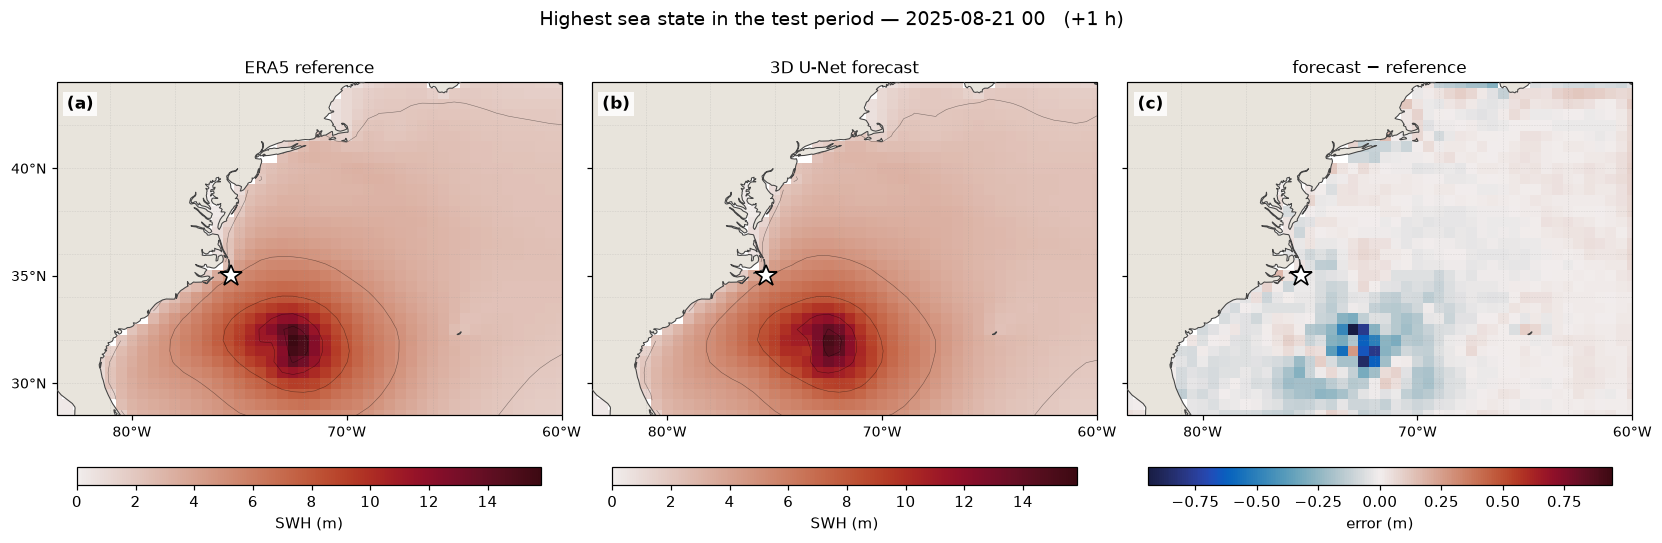

peak SWH: ERA5 15.84 m, 3D U-Net 15.21 m (-0.63 m at the maximum)


In [5]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter

# cmocean: perceptually uniform, so an equal step in colour is an equal step in
# wave height. Rainbow/jet maps invent boundaries where the field is smooth and
# are unreadable to colourblind readers.
CMAP_SWH, CMAP_ERR = cmocean.cm.amp, cmocean.cm.balance
POINT_LAT, POINT_LON = 35.01, -75.40      # Cape Hatteras

ocean = D["ocean"].astype(bool)
k = int(np.nanargmax(np.nanmax(np.where(MASK, D["true"], np.nan), axis=(1, 2))))
when = str(D["times"][k])[:16].replace("T", " ")

true_f = np.where(ocean, D["true"][k], np.nan)
pred_f = np.where(ocean, D["3D U-Net"][k], np.nan)
err_f = pred_f - true_f
lats = LAT_MIN + np.arange(N_LAT) * GRID_RES
lons = LON_MIN + np.arange(N_LON) * GRID_RES
vmax, elim = np.nanmax(true_f), np.nanmax(np.abs(err_f))

proj = ccrs.PlateCarree()
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), subplot_kw={"projection": proj},
                         constrained_layout=True)
panels = [(true_f, "ERA5 reference", CMAP_SWH, dict(vmin=0, vmax=vmax), "SWH (m)"),
          (pred_f, "3D U-Net forecast", CMAP_SWH, dict(vmin=0, vmax=vmax), "SWH (m)"),
          (err_f, "forecast $-$ reference", CMAP_ERR,
           dict(vmin=-elim, vmax=elim), "error (m)")]

for n, (ax, (field, title, cmap, kw, cbl)) in enumerate(zip(axes, panels)):
    ax.set_extent([lons[0], lons[-1], lats[0], lats[-1]], crs=proj)
    m = ax.pcolormesh(lons, lats, field, cmap=cmap, shading="nearest",
                      transform=proj, rasterized=True, **kw)
    if n < 2:
        ax.contour(lons, lats, field, levels=np.arange(2, vmax, 3), colors="k",
                   linewidths=0.35, alpha=0.45, transform=proj)
    ax.add_feature(cfeature.LAND, facecolor="#e8e4dc", zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7, edgecolor="#444", zorder=3)
    ax.gridlines(linewidth=0.4, color="#9a9a9a", alpha=0.45, linestyle=":")
    ax.set_xticks(np.arange(-80, -59, 10), crs=proj)
    ax.set_yticks(np.arange(30, 45, 5), crs=proj)
    ax.xaxis.set_major_formatter(LongitudeFormatter())
    ax.yaxis.set_major_formatter(LatitudeFormatter())
    ax.tick_params(labelsize=9)
    if n:
        ax.set_yticklabels([])
    ax.plot(POINT_LON, POINT_LAT, marker="*", ms=15, color="w", mec="k",
            mew=1.1, transform=proj, zorder=4)
    ax.set_title(title, fontsize=11, pad=6)
    ax.text(0.02, 0.96, f"({'abc'[n]})", transform=ax.transAxes, va="top",
            fontsize=11, fontweight="bold", zorder=5,
            bbox=dict(boxstyle="square,pad=0.22", fc="white", ec="none", alpha=.85))
    fig.colorbar(m, ax=ax, orientation="horizontal", pad=0.06, aspect=26,
                 shrink=0.92, label=cbl)

fig.suptitle(f"Highest sea state in the test period — {when}   (+{LEAD} h)",
             fontsize=12.5)
plt.show()

print(f"peak SWH: ERA5 {np.nanmax(true_f):.2f} m, "
      f"3D U-Net {np.nanmax(pred_f):.2f} m "
      f"({np.nanmax(pred_f) - np.nanmax(true_f):+.2f} m at the maximum)")

### Figure 2 — where each model makes its errors

A single number per model hides the fact that they fail in different places.
This is the error averaged over the whole test period, cell by cell.

The three panels share one colour scale, so they are directly comparable.

C:\Users\Minghao\AppData\Local\Temp\ipykernel_38956\429131022.py:6: RuntimeWarning: Mean of empty slice
  mae_maps[name] = np.nanmean(e, axis=0)


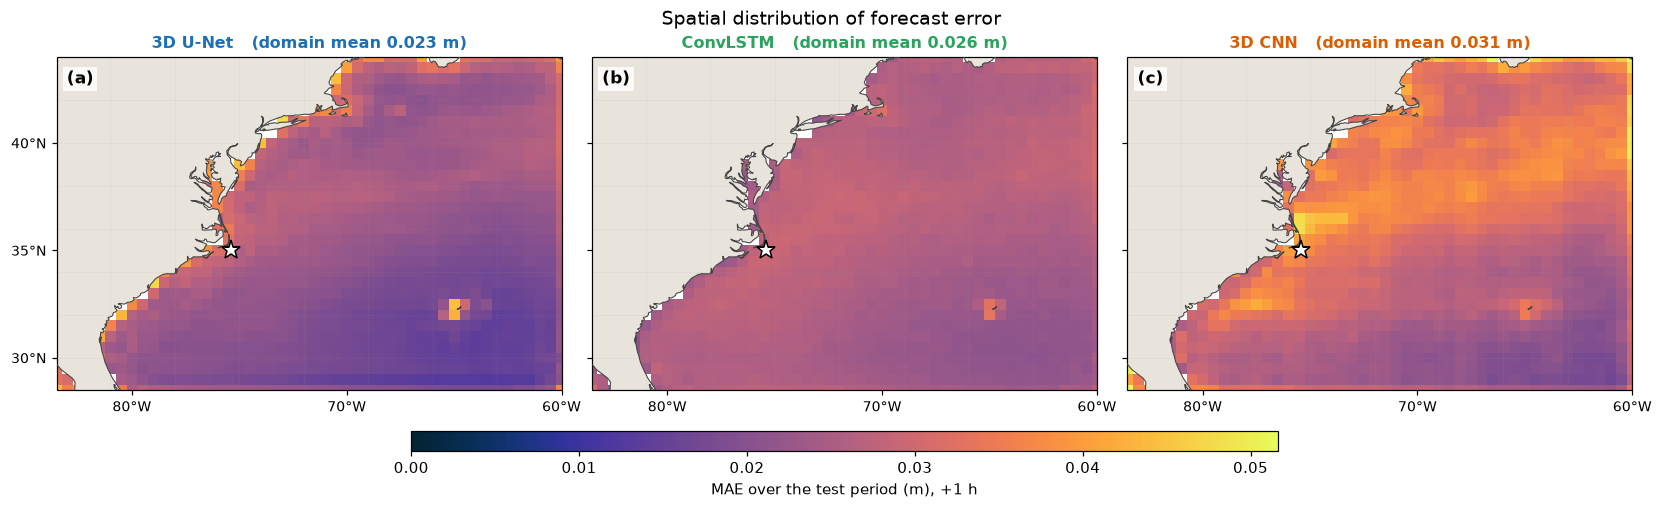

In [6]:
mae_maps, vhi = {}, 0.0
for name in MODELS:
    e = np.abs(D[name] - D["true"])
    e = np.where(MASK, e, np.nan)
    with np.errstate(invalid="ignore"):
        mae_maps[name] = np.nanmean(e, axis=0)
    vhi = max(vhi, np.nanpercentile(mae_maps[name], 99.5))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), subplot_kw={"projection": proj},
                         constrained_layout=True)
for n, (ax, name) in enumerate(zip(axes, MODELS)):
    field = np.where(ocean, mae_maps[name], np.nan)
    m = ax.pcolormesh(lons, lats, field, cmap=cmocean.cm.thermal, vmin=0,
                      vmax=vhi, shading="nearest", transform=proj, rasterized=True)
    ax.set_extent([lons[0], lons[-1], lats[0], lats[-1]], crs=proj)
    ax.add_feature(cfeature.LAND, facecolor="#e8e4dc", zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7, edgecolor="#444", zorder=3)
    ax.gridlines(linewidth=0.4, color="#9a9a9a", alpha=0.4, linestyle=":")
    ax.set_xticks(np.arange(-80, -59, 10), crs=proj)
    ax.set_yticks(np.arange(30, 45, 5), crs=proj)
    ax.xaxis.set_major_formatter(LongitudeFormatter())
    ax.yaxis.set_major_formatter(LatitudeFormatter())
    ax.tick_params(labelsize=9)
    if n:
        ax.set_yticklabels([])
    ax.plot(POINT_LON, POINT_LAT, marker="*", ms=13, color="w", mec="k",
            mew=1.0, transform=proj, zorder=4)
    ax.set_title(f"{name}   (domain mean {np.nanmean(field):.3f} m)",
                 fontsize=10.5, color=COLOUR[name], fontweight="bold")
    ax.text(0.02, 0.96, f"({'abc'[n]})", transform=ax.transAxes, va="top",
            fontsize=11, fontweight="bold", zorder=5,
            bbox=dict(boxstyle="square,pad=0.22", fc="white", ec="none", alpha=.85))

fig.colorbar(m, ax=axes, orientation="horizontal", pad=0.04, aspect=45,
             shrink=0.55, label=f"MAE over the test period (m), +{LEAD} h")
fig.suptitle("Spatial distribution of forecast error", fontsize=12.5)
plt.show()

The domain averages are close, but the *patterns* are not. Compare where each
model concentrates its error — the shelf edge, the Gulf Stream front, the open
ocean — and whether the worst cells sit in the same place for all three.

### Figure 3 — the same storm as a time series

All three models at the Cape Hatteras grid cell, through the roughest stretch
of the test period. This is where architectures separate: they agree in calm
conditions and disagree at the peak.

**Try changing** `POINT_LAT` / `POINT_LON` to somewhere else in the domain and
re-running this cell.

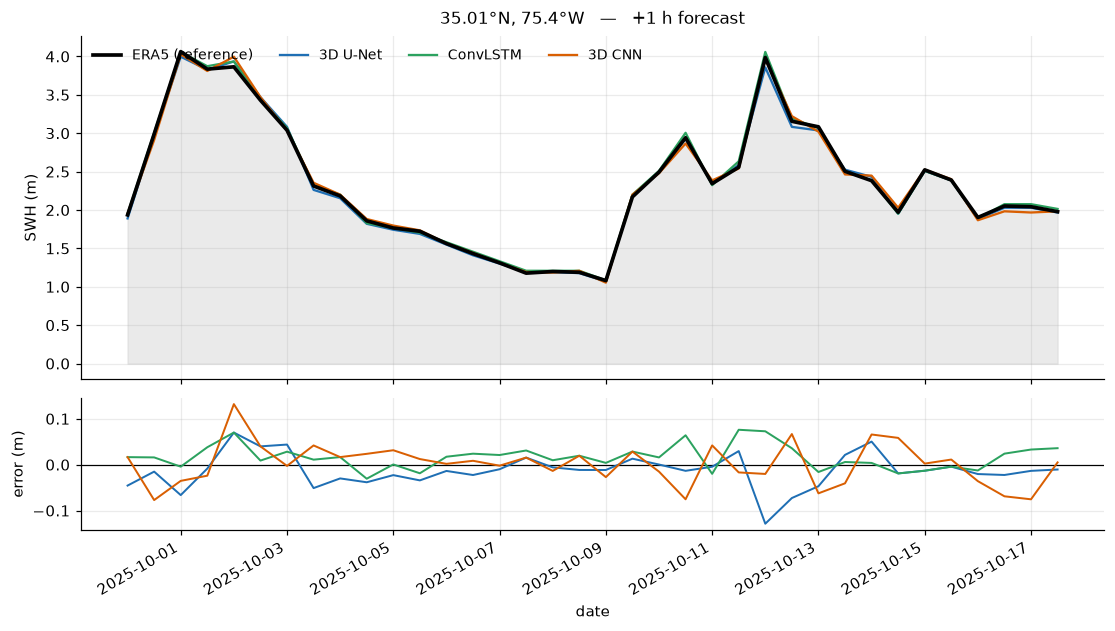

at the peak (2025-10-01T00, ERA5 4.06 m):
  3D U-Net    4.00 m   (-0.07 m)
  ConvLSTM    4.06 m   (-0.00 m)
  3D CNN      4.03 m   (-0.04 m)


In [7]:
i = int(round((POINT_LAT - LAT_MIN) / GRID_RES))
j = int(round((POINT_LON - LON_MIN) / GRID_RES))
truth_p = D["true"][:, i, j]
times = D["times"].astype("datetime64[h]")

step_h = max(1, int(np.median(np.diff(D["t_index"]))))
span = max(8, (18 * 24) // step_h)
roll = np.convolve(truth_p, np.ones(span) / span, mode="valid")
sl = slice(int(np.argmax(roll)), int(np.argmax(roll)) + span)

fig, ax = plt.subplots(2, 1, figsize=(12, 6.6), sharex=True,
                       gridspec_kw={"height_ratios": [3, 1.15], "hspace": 0.08})

ax[0].fill_between(times[sl], 0, truth_p[sl], color="#d9d9d9", alpha=.55)
ax[0].plot(times[sl], truth_p[sl], "k", lw=2.4, label="ERA5 (reference)", zorder=5)
for n in MODELS:
    ax[0].plot(times[sl], D[n][:, i, j][sl], color=COLOUR[n], lw=1.5, label=n)
ax[0].set_ylabel("SWH (m)")
ax[0].legend(loc="upper left", frameon=False, ncol=4, fontsize=9)
ax[0].set_title(f"{POINT_LAT}°N, {abs(POINT_LON)}°W   —   +{LEAD} h forecast",
                pad=8)
ax[0].grid(alpha=.25)

ax[1].axhline(0, color="k", lw=.8)
for n in MODELS:
    ax[1].plot(times[sl], D[n][:, i, j][sl] - truth_p[sl], color=COLOUR[n], lw=1.3)
ax[1].set_ylabel("error (m)"); ax[1].set_xlabel("date"); ax[1].grid(alpha=.25)

fig.autofmt_xdate()
plt.show()

peak = int(np.argmax(truth_p[sl])) + sl.start
print(f"at the peak ({str(times[peak])[:13]}, ERA5 {truth_p[peak]:.2f} m):")
for n in MODELS:
    print(f"  {n:<10} {D[n][peak, i, j]:5.2f} m   "
          f"({D[n][peak, i, j] - truth_p[peak]:+.2f} m)")

### Figure 4 — every forecast against the reference

One point per grid cell per hour; colour is how many points land in each
hexagon. A perfect forecast sits on the dashed 1:1 line. `SI` is the scatter
index — the error standard deviation divided by the mean wave height.

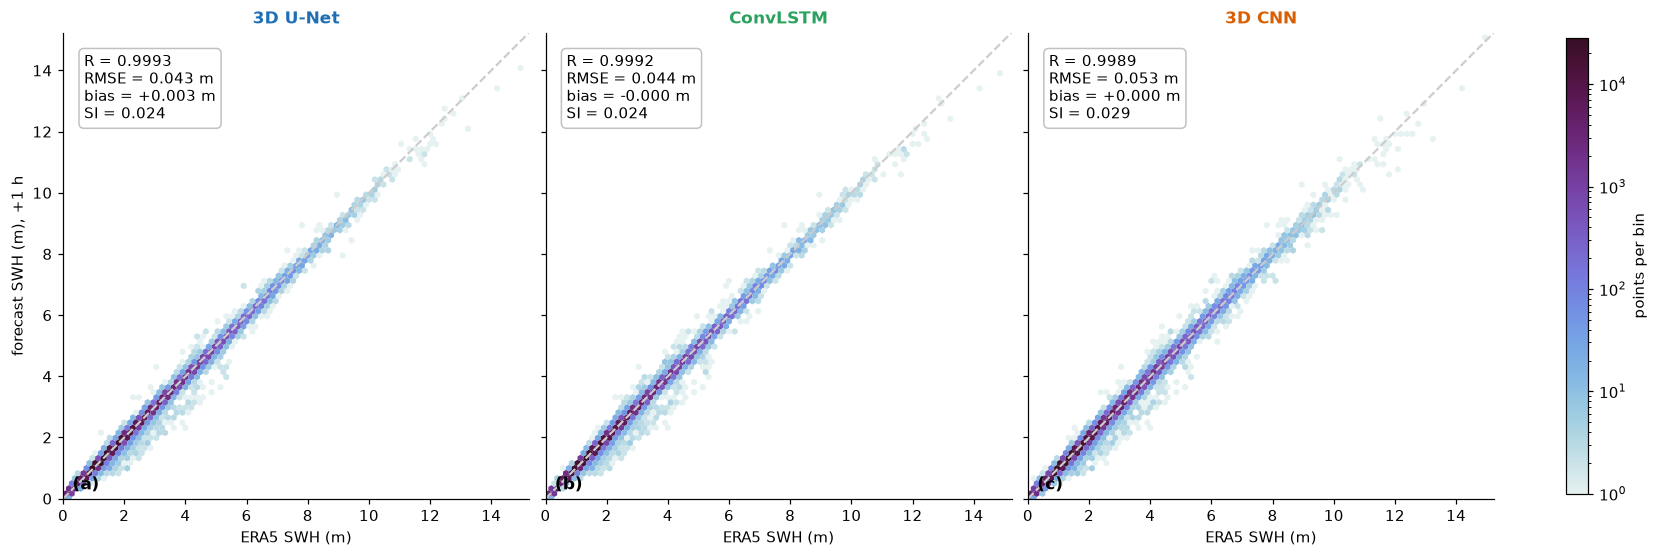

In [8]:
step = max(1, len(TRUE) // 350_000)
t_s = TRUE[::step]
top = t_s.max() * 1.02

fig, axes = plt.subplots(1, 3, figsize=(15, 5.1), sharex=True, sharey=True,
                         constrained_layout=True)
for n, (ax, name) in enumerate(zip(axes, MODELS)):
    y = PRED[name][::step]
    hb = ax.hexbin(t_s, y, gridsize=80, bins="log", mincnt=1,
                   cmap=cmocean.cm.dense, linewidths=0, extent=(0, top, 0, top))
    ax.plot([0, top], [0, top], "--", color="#cccccc", lw=1.4)
    s = scores(y, t_s)
    ax.text(0.045, 0.955,
            f"R = {s['corr']:.4f}\nRMSE = {s['rmse']:.3f} m\n"
            f"bias = {s['bias']:+.3f} m\nSI = {s['si']:.3f}",
            transform=ax.transAxes, va="top", fontsize=9.5,
            bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="#bbb", alpha=.9))
    ax.set_xlim(0, top); ax.set_ylim(0, top); ax.set_aspect("equal")
    ax.set_xlabel("ERA5 SWH (m)")
    ax.set_title(name, color=COLOUR[name], fontweight="bold")
    ax.text(0.02, 0.02, f"({'abc'[n]})", transform=ax.transAxes, fontsize=11,
            fontweight="bold")
axes[0].set_ylabel(f"forecast SWH (m), +{LEAD} h")
fig.colorbar(hb, ax=axes, location="right", shrink=0.85, label="points per bin")
plt.show()

### Figure 5 — where the error lives

Aggregate scores are dominated by the calm 99% of the record. Splitting the
error by how rough the sea actually was tells a different story.

**(a)** error size against sea state. **(b)** the *signed* error — below zero
means the model predicts a smaller wave than the reference. **(c)** how much of
the record sits in each bin, which is why (a) and (b) barely move the headline
number.

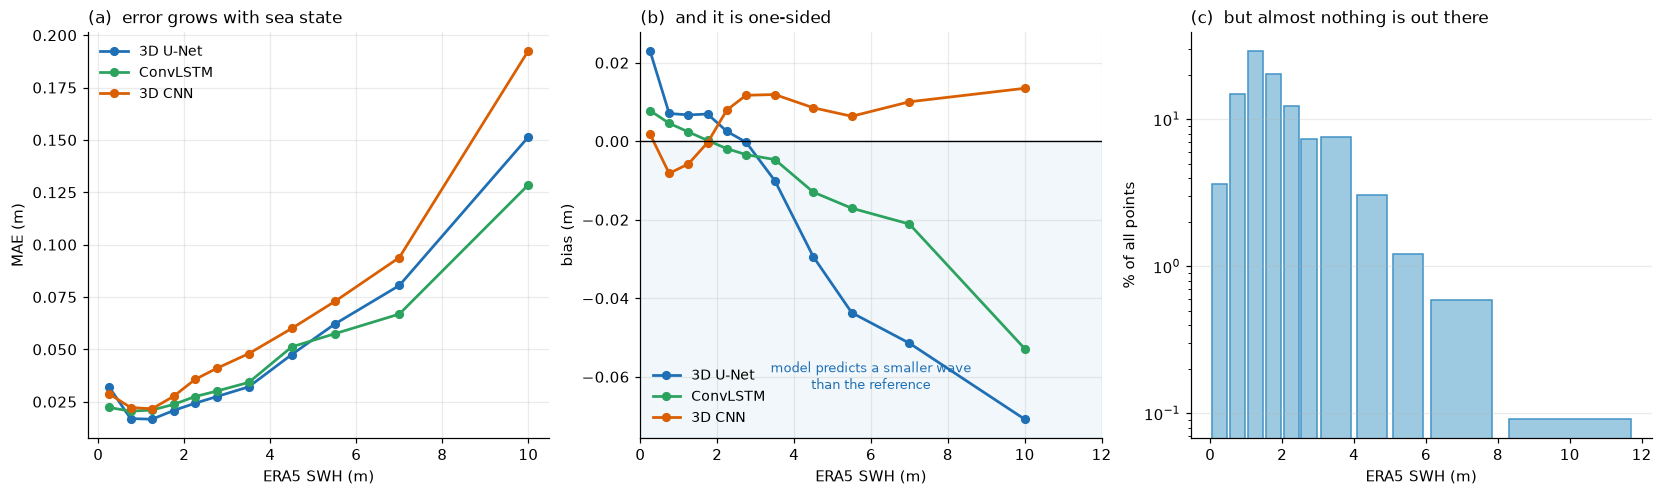

In [9]:
step = max(1, len(TRUE) // 500_000)
t_ = TRUE[::step]
edges = np.array([0, .5, 1, 1.5, 2, 2.5, 3, 4, 5, 6, 8, 12])
ctr = 0.5 * (edges[:-1] + edges[1:])

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), constrained_layout=True)

for name in MODELS:
    p_ = PRED[name][::step]
    mae, bias = [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        sel = (t_ >= lo) & (t_ < hi)
        mae.append(np.mean(np.abs(p_[sel] - t_[sel])) if sel.sum() > 50 else np.nan)
        bias.append(np.mean(p_[sel] - t_[sel]) if sel.sum() > 50 else np.nan)
    axes[0].plot(ctr, mae, "o-", color=COLOUR[name], lw=1.8, ms=5, label=name)
    axes[1].plot(ctr, bias, "o-", color=COLOUR[name], lw=1.8, ms=5, label=name)

axes[0].set_xlabel("ERA5 SWH (m)"); axes[0].set_ylabel("MAE (m)")
axes[0].set_title("(a)  error grows with sea state", loc="left")
axes[0].legend(frameon=False, fontsize=9); axes[0].grid(alpha=.25)

axes[1].axhline(0, color="k", lw=.9)
axes[1].set_xlim(0, 12)
# Shade the negative half *after* the data has set the limits, otherwise the
# shading dictates the y-range and squashes the curves into a line.
lo, hi = axes[1].get_ylim()
axes[1].axhspan(lo, 0, color="#4292c6", alpha=.07, zorder=0)
axes[1].set_ylim(lo, hi)
axes[1].set_xlabel("ERA5 SWH (m)"); axes[1].set_ylabel("bias (m)")
axes[1].set_title("(b)  and it is one-sided", loc="left")
axes[1].annotate("model predicts a smaller wave\nthan the reference",
                 xy=(0.5, 0.12), xycoords="axes fraction", fontsize=8.5,
                 color="#1f6fb4", ha="center")
axes[1].legend(frameon=False, fontsize=9, loc="lower left")
axes[1].grid(alpha=.25)

counts, _ = np.histogram(t_, bins=edges)
axes[2].bar(ctr, 100 * counts / counts.sum(), width=np.diff(edges) * .85,
            color="#9ecae1", edgecolor="#4292c6")
axes[2].set_yscale("log")
axes[2].set_xlabel("ERA5 SWH (m)"); axes[2].set_ylabel("% of all points")
axes[2].set_title("(c)  but almost nothing is out there", loc="left")
axes[2].grid(alpha=.25, axis="y")

plt.show()

Panel (b) is the one worth staring at. **The two accurate models drift steadily
negative as the sea gets rougher** — by 10 m the 3D U-Net is short by about
7 cm and the ConvLSTM by 5 cm, and the trend is still going. Neither ever
swings positive.

That is the expected behaviour of a network trained on mean squared error: when
the outcome is uncertain, the score-minimising guess is the conditional
average, so forecasts get pulled toward the middle of the distribution. The
effect is small at +1 h, but it compounds with lead time — the table in
section 4 shows the same bias reaching metres at +48 h.

The 3D CNN is the exception, and not in a flattering way: its bias stays
slightly positive while its MAE in panel (a) is the worst of the three. It is
not better calibrated, just noisier, so its errors do not cancel in one
direction.

Panel (c) explains why none of this shows up in the headline number: waves
above 4 m are a fraction of a percent of the record.

### Figure 6 — how the models learned

Thin lines are training loss, thick lines validation loss, on a log scale.

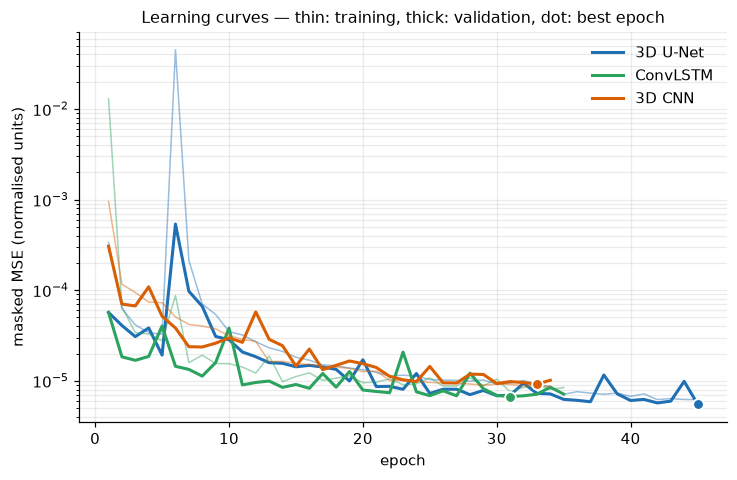

  model         epochs  best epoch   val MAE (m)
  3D U-Net          45          45         0.020
  ConvLSTM          35          31         0.026
  3D CNN            34          33         0.030


In [10]:
from train import LOGS

# A model whose log is absent (never trained, or retraining in progress) is
# skipped rather than raising.
histories = {}
for name, ckpt in MODELS.items():
    path = LOGS / f"{ckpt}.json"
    if path.exists():
        histories[name] = json.loads(path.read_text())
    else:
        print(f"{name}: no training log yet")

if not histories:
    print("no training logs available")
else:
    fig, ax = plt.subplots(figsize=(7.6, 4.6))
    for name, h in histories.items():
        ep = [r["epoch"] for r in h]
        ax.plot(ep, [r["train_loss"] for r in h], color=COLOUR[name], lw=1,
                alpha=.45)
        ax.plot(ep, [r["val_loss"] for r in h], color=COLOUR[name], lw=2,
                label=name)
        best = min(range(len(h)), key=lambda i: h[i]["val_loss"])
        ax.plot(ep[best], h[best]["val_loss"], "o", color=COLOUR[name], ms=7,
                mec="white", mew=1.2, zorder=5)

    ax.set_yscale("log")
    ax.set_xlabel("epoch"); ax.set_ylabel("masked MSE (normalised units)")
    ax.set_title("Learning curves — thin: training, thick: validation, "
                 "dot: best epoch", fontsize=10.5)
    ax.legend(frameon=False); ax.grid(alpha=.25, which="both")
    plt.show()

    print(f"  {'model':<12}{'epochs':>8}{'best epoch':>12}{'val MAE (m)':>14}")
    for name, h in histories.items():
        b = min(h, key=lambda r: r["val_loss"])
        print(f"  {name:<12}{len(h):>8}{b['epoch']:>12}{b['val_mae']:>14.3f}")

## 4. Forecasting further ahead

The 3D U-Net trained separately for +1, +6, +24 and +48 hour lead times.

lead,MAE (m),RMSE (m),R²,MAE in top 1% (m),bias in top 1% (m)
+1 h,0.020,0.037,0.999,0.06,+0.00
+6 h,0.082,0.132,0.985,0.31,-0.07
+24 h,0.332,0.513,0.779,1.72,-1.63
+48 h,0.541,0.806,0.455,3.52,-3.52


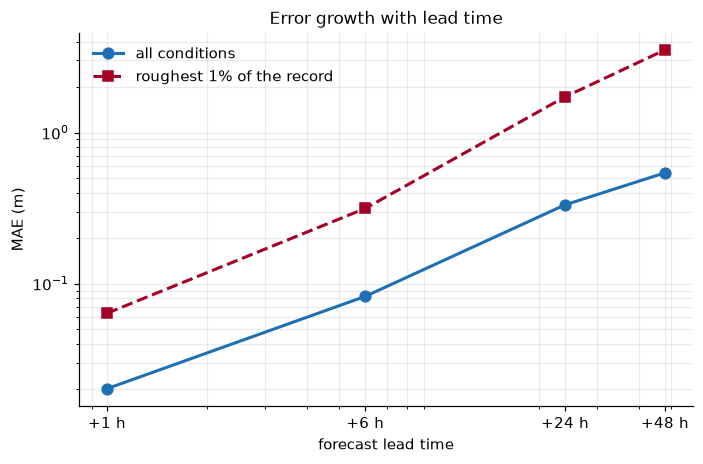

In [11]:
LEADS = (1, 6, 24, 48)

# Skip lead times whose metrics are missing rather than raising. Each lead has
# its own table, regenerated by predict.py, so one that has not been scored yet
# -- or whose checkpoint is mid-retraining -- simply drops out of the plot.
rows, absent = [], []
for L in LEADS:
    path = TABLES / f"test_metrics_swh_h{L}.csv"
    if not path.exists():
        absent.append((L, "no metrics file"))
        continue
    df = pd.read_csv(path)
    sel = df["model"].str.startswith("unet3d_swh_full")
    r = df[(df["stratum"] == "all") & sel]
    p99 = df[(df["stratum"] == "P99+") & sel]
    if r.empty or p99.empty:
        absent.append((L, "no 3D U-Net row"))
        continue
    r, p99 = r.iloc[0], p99.iloc[0]
    rows.append({"lead": L, "MAE (m)": r["mae"], "RMSE (m)": r["rmse"],
                 "R²": r["r2"], "MAE in top 1% (m)": p99["mae"],
                 "bias in top 1% (m)": p99["bias"]})

for L, why in absent:
    print(f"+{L} h skipped — {why}")
if absent:
    print("  regenerate with:  python src/compare_models.py --all-leads\n")

if not rows:
    print("no lead times available yet")
else:
    tbl = pd.DataFrame(rows)
    display(tbl.assign(lead=[f"+{L} h" for L in tbl["lead"]])
            .style.format({"MAE (m)": "{:.3f}", "RMSE (m)": "{:.3f}",
                           "R²": "{:.3f}", "MAE in top 1% (m)": "{:.2f}",
                           "bias in top 1% (m)": "{:+.2f}"})
            .hide(axis="index")
            .set_caption("3D U-Net across lead times"))

    fig, ax = plt.subplots(figsize=(7.2, 4.4))
    ax.plot(tbl["lead"], tbl["MAE (m)"], "o-", color=COLOUR["3D U-Net"],
            lw=2, ms=7, label="all conditions")
    ax.plot(tbl["lead"], tbl["MAE in top 1% (m)"], "s--", color="#a50026",
            lw=2, ms=6, label="roughest 1% of the record")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xticks(tbl["lead"])
    ax.set_xticklabels([f"+{L} h" for L in tbl["lead"]])
    ax.set_xlabel("forecast lead time"); ax.set_ylabel("MAE (m)")
    ax.set_title("Error growth with lead time")
    ax.legend(frameon=False); ax.grid(alpha=.25, which="both")
    plt.show()

The gap between the two curves widens with lead time. At +1 h the roughest 1%
costs about four times the average error; by +48 h it is closer to seven times,
and the bias column in the table shows almost all of that is under-prediction.

## 5. Checking against real measurements

Everything so far has compared forecasts against ERA5. But ERA5 is itself a
wave model, corrected with satellite data — so those numbers say how well we
reproduce ERA5, not how well we reproduce the ocean.

**NDBC buoys** are the closest thing to a direct measurement available here.
Thirteen of them sit inside the domain, and unlike the altimeters that ERA5
assimilates, they are largely independent of it.

*Generated by* `python src/buoys.py` then `python src/validate_buoys.py`

> One caveat when reading these numbers. A buoy measures a single point; an
> ERA5 cell is an average over roughly 56 × 46 km. During a storm the point can
> genuinely exceed the cell average, so part of any difference is a mismatch of
> scale rather than a model error.

In [12]:
buoy = pd.read_parquet(ROOT / "data/interim/buoy_matched.parquet")

print(f"{len(buoy):,} paired hours from {buoy['station'].nunique()} stations, "
      f"{buoy['time'].dt.year.min()}–{buoy['time'].dt.year.max()}\n")

per_station = (buoy.groupby(["station", "name", "setting"])
               .apply(lambda g: pd.Series({
                   "hours": len(g),
                   "buoy mean (m)": g["WVHT"].mean(),
                   "ERA5 mean (m)": g["era5_swh"].mean(),
                   "bias (m)": (g["era5_swh"] - g["WVHT"]).mean(),
                   "MAE (m)": (g["era5_swh"] - g["WVHT"]).abs().mean(),
                   "R": g["era5_swh"].corr(g["WVHT"])}),
                      include_groups=False)
               .reset_index()
               .sort_values("bias (m)"))

display(per_station.style.format({
    "hours": "{:,.0f}", "buoy mean (m)": "{:.2f}", "ERA5 mean (m)": "{:.2f}",
    "bias (m)": "{:+.3f}", "MAE (m)": "{:.3f}", "R": "{:.3f}"})
    .hide(axis="index")
    .set_caption("ERA5 against each buoy — bias is ERA5 minus buoy"))

434,662 paired hours from 12 stations, 2020–2025



station,name,setting,hours,buoy mean (m),ERA5 mean (m),bias (m),MAE (m),R
44095,"Oregon Inlet, NC",shelf,"43,515",1.33,0.99,-0.342,0.359,0.911
44100,"Duck FRF 26m, NC",nearshore,"38,962",1.16,1.12,-0.047,0.169,0.939
44014,"Virginia Beach, VA",shelf,"36,791",1.43,1.39,-0.039,0.164,0.958
41001,E of Cape Hatteras,offshore,"25,511",1.79,1.76,-0.036,0.197,0.956
44008,Nantucket SE,offshore,"38,558",1.73,1.71,-0.022,0.187,0.968
41048,W Bermuda,offshore,"23,395",1.84,1.83,-0.013,0.175,0.966
41002,S Hatteras,offshore,"37,089",1.71,1.72,+0.012,0.183,0.957
41025,"Diamond Shoals, NC",shelf,"27,926",1.51,1.52,+0.013,0.209,0.918
41013,"Frying Pan Shoals, NC",shelf,"43,523",1.33,1.40,+0.071,0.161,0.951
41004,"Edisto, SC",shelf,"39,127",1.28,1.36,+0.076,0.168,0.951


Overall ERA5 tracks the buoys closely (R ≈ 0.9–0.97). The interesting part is
what happens when the sea gets rough.

In [13]:
SEA_STATE = [("1–3  (0–1.25 m)", 0.0, 1.25), ("4    (1.25–2.5 m)", 1.25, 2.5),
             ("5    (2.5–4 m)", 2.5, 4.0), ("6+   (>4 m)", 4.0, 99.0)]

b = buoy["WVHT"].to_numpy()
e = buoy["era5_swh"].to_numpy()

rows = []
for label, lo, hi in SEA_STATE:
    s = (b >= lo) & (b < hi)
    if s.sum() < 30:
        continue
    err = e[s] - b[s]
    rows.append({"sea state (WMO)": label, "hours": int(s.sum()),
                 "buoy mean (m)": b[s].mean(), "bias (m)": err.mean(),
                 "MAE (m)": np.abs(err).mean(),
                 "MAPE (%)": 100 * np.mean(np.abs(err / b[s]))})
display(pd.DataFrame(rows).style.format({
    "hours": "{:,.0f}", "buoy mean (m)": "{:.2f}", "bias (m)": "{:+.3f}",
    "MAE (m)": "{:.3f}", "MAPE (%)": "{:.1f}"}).hide(axis="index")
    .set_caption("ERA5 against the buoys, by WMO sea state"))

sea state (WMO),hours,buoy mean (m),bias (m),MAE (m),MAPE (%)
1–3 (0–1.25 m),"228,591",0.86,+0.054,0.142,18.3
4 (1.25–2.5 m),"167,727",1.71,-0.058,0.222,13.0
5 (2.5–4 m),"31,777",3.03,-0.196,0.382,12.6
6+ (>4 m),"6,567",4.83,-0.418,0.619,12.8


**ERA5 under-predicts the rough seas**, and the shortfall grows with sea state
— reaching roughly half a metre above 4 m. This is consistent with what the
literature reports about reanalysis wave heights in high sea states.

That matters for everything earlier in this notebook: the models were trained
to reproduce ERA5, so any bias already in ERA5 is inherited before the network
sees a single wave.

### 5.1 What was inherited, and what was learned

With buoys as a third reference the shortfall splits into two parts:

| term | meaning |
|---|---|
| `ERA5 − buoy` | bias already present in the **training target** |
| `model − ERA5` | bias **introduced** by learning it |
| `model − buoy` | what a user of the forecast actually gets |

The first does not depend on lead time — it is a property of the reanalysis.
The second grows as the forecast reaches further ahead. **Where they cross is
where effort should move from better training data to a better model.**

*Generated by* `python src/bias_decomposition.py`

lead (h),hours,ERA5 − buoy (m),model − ERA5 (m),model − buoy (m),inherited
1,559,-0.455,-0.017,-0.472,96%
6,566,-0.401,-0.036,-0.438,92%
24,544,-0.453,-0.838,-1.291,35%
48,544,-0.453,-2.130,-2.583,18%


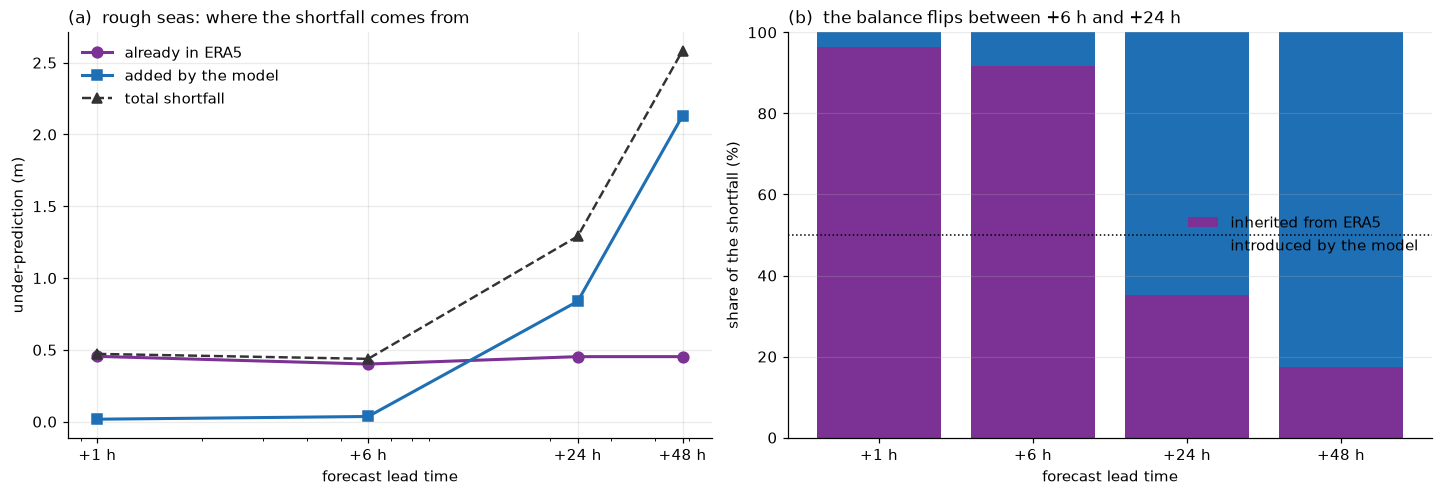

In [14]:
dec = pd.read_csv(TABLES / "bias_decomposition.csv")
rough = dec[dec["sea_state"].str.startswith("6+")].copy()

view = rough[["lead", "n", "era5_minus_buoy", "model_minus_era5",
              "model_minus_buoy", "inherited_share"]].copy()
view.columns = ["lead (h)", "hours", "ERA5 − buoy (m)", "model − ERA5 (m)",
                "model − buoy (m)", "inherited"]
display(view.style.format({
    "hours": "{:,.0f}", "ERA5 − buoy (m)": "{:+.3f}",
    "model − ERA5 (m)": "{:+.3f}", "model − buoy (m)": "{:+.3f}",
    "inherited": "{:.0%}"}).hide(axis="index")
    .set_caption("Rough seas (>4 m at the buoy) — 3D U-Net"))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), constrained_layout=True)

ax = axes[0]
ax.plot(rough["lead"], -rough["era5_minus_buoy"], "o-", color="#7b3294", lw=2,
        ms=7, label="already in ERA5")
ax.plot(rough["lead"], -rough["model_minus_era5"], "s-", color=COLOUR["3D U-Net"],
        lw=2, ms=7, label="added by the model")
ax.plot(rough["lead"], -rough["model_minus_buoy"], "^--", color="#333", lw=1.6,
        ms=6, label="total shortfall")
ax.set_xscale("log"); ax.set_xticks(rough["lead"])
ax.set_xticklabels([f"+{int(L)} h" for L in rough["lead"]])
ax.set_xlabel("forecast lead time")
ax.set_ylabel("under-prediction (m)")
ax.set_title("(a)  rough seas: where the shortfall comes from", loc="left")
ax.legend(frameon=False); ax.grid(alpha=.25)

ax = axes[1]
ax.bar(range(len(rough)), 100 * rough["inherited_share"], color="#7b3294",
       label="inherited from ERA5")
ax.bar(range(len(rough)), 100 * (1 - rough["inherited_share"]),
       bottom=100 * rough["inherited_share"], color=COLOUR["3D U-Net"],
       label="introduced by the model")
ax.axhline(50, color="k", lw=1, ls=":")
ax.set_xticks(range(len(rough)))
ax.set_xticklabels([f"+{int(L)} h" for L in rough["lead"]])
ax.set_ylim(0, 100); ax.set_ylabel("share of the shortfall (%)")
ax.set_xlabel("forecast lead time")
ax.set_title("(b)  the balance flips between +6 h and +24 h", loc="left")
ax.legend(frameon=False, loc="center right"); ax.grid(alpha=.25, axis="y")

plt.show()

**At short range the model has essentially nothing left to win.** At +1 h, 96%
of the shortfall in rough seas was already in ERA5; the network adds 1.7 cm on
top of a 45 cm inherited bias. No amount of architecture work recovers more
than that last few percent — the way forward there is a better training target,
not a better network.

**Beyond about a day the model becomes the problem.** By +24 h it contributes
two thirds of the shortfall, and by +48 h more than four fifths. That is the
range where a better model — physical constraints, a different loss, an
architecture that respects wave dynamics — has something to work with.

The crossover sits between +6 h and +24 h.

One more thing worth noticing in the full table: at the calmest sea states the
model's contribution is **positive** at long range (+0.12 m at +24 h, +0.25 m
at +48 h) while it is strongly negative in rough seas. The forecast is being
pulled toward the middle of the distribution from both ends — over-predicting
small waves and under-predicting large ones, which is what a mean-squared-error
objective rewards when the outcome is uncertain.

## 6. Summary

| | |
|---|---|
| Best +1 h forecast | 3D U-Net, **MAE 0.021 m**, R = 0.999 |
| Architecture ranking | U-Net ≈ ConvLSTM > 3D CNN — skip connections matter more than convolution vs recurrence |
| Largest single effect | including SWH among the inputs (**+83%** error without it) |
| Consistent weakness | the two accurate models under-predict large waves, and the shortfall grows with both sea state and lead time |

### Things to be careful about

1. **The reference is a model, not the ocean.** ERA5 is itself a wave model
   constrained by satellites, so these numbers say how well we reproduce ERA5,
   not how well we reproduce reality. Comparing against buoy measurements is
   the natural next step.
2. **The grid is coarse.** Each cell is roughly 56 × 46 km — far too coarse for
   anything happening at the shoreline.
3. **An R² of 0.999 is less impressive than it sounds.** Most of that variance
   is the ordinary seasonal and spatial pattern of the wave field, which is
   easy. Figure 5 is the honest view.